#### Libraries

In [2]:
# Prevent OpenMP runtime conflict between libraries like PyTorch, TensorFlow, and NumPy on Windows
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from libraries import *

#### Dataset

In [3]:
# Extract dataset.zip
with zipfile.ZipFile('dataset.zip', 'r') as zip_ref:
    zip_ref.extractall()

In [4]:
# Read Dataset
df = pd.read_csv('./dataset/train.csv')
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
1,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
2,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
3,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
4,75.0,1,246,0,15,0,127000.00,1.2,137,1,0,10,1


In [5]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000
mean,59.906293,0.409639,565.594378,0.393574,38.405622,0.365462,257685.512932,1.385783,136.526104,0.630522,0.313253,130.481928,0.313253
std,11.539249,0.492757,927.736276,0.489526,11.949833,0.482529,89331.766264,1.061953,4.326438,0.483636,0.464750,77.274181,0.464750
min,40.000000,0.000000,30.000000,0.000000,14.000000,0.000000,25100.000000,0.500000,113.000000,0.000000,0.000000,6.000000,0.000000
25%,50.000000,0.000000,118.000000,0.000000,30.000000,0.000000,213000.000000,0.900000,134.000000,0.000000,0.000000,73.000000,0.000000
50%,60.000000,0.000000,246.000000,0.000000,38.000000,0.000000,255000.000000,1.100000,137.000000,1.000000,0.000000,113.000000,0.000000
75%,68.000000,1.000000,582.000000,1.000000,45.000000,1.000000,297000.000000,1.400000,139.000000,1.000000,1.000000,205.000000,1.000000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,742000.000000,9.400000,148.000000,1.000000,1.000000,285.000000,1.000000


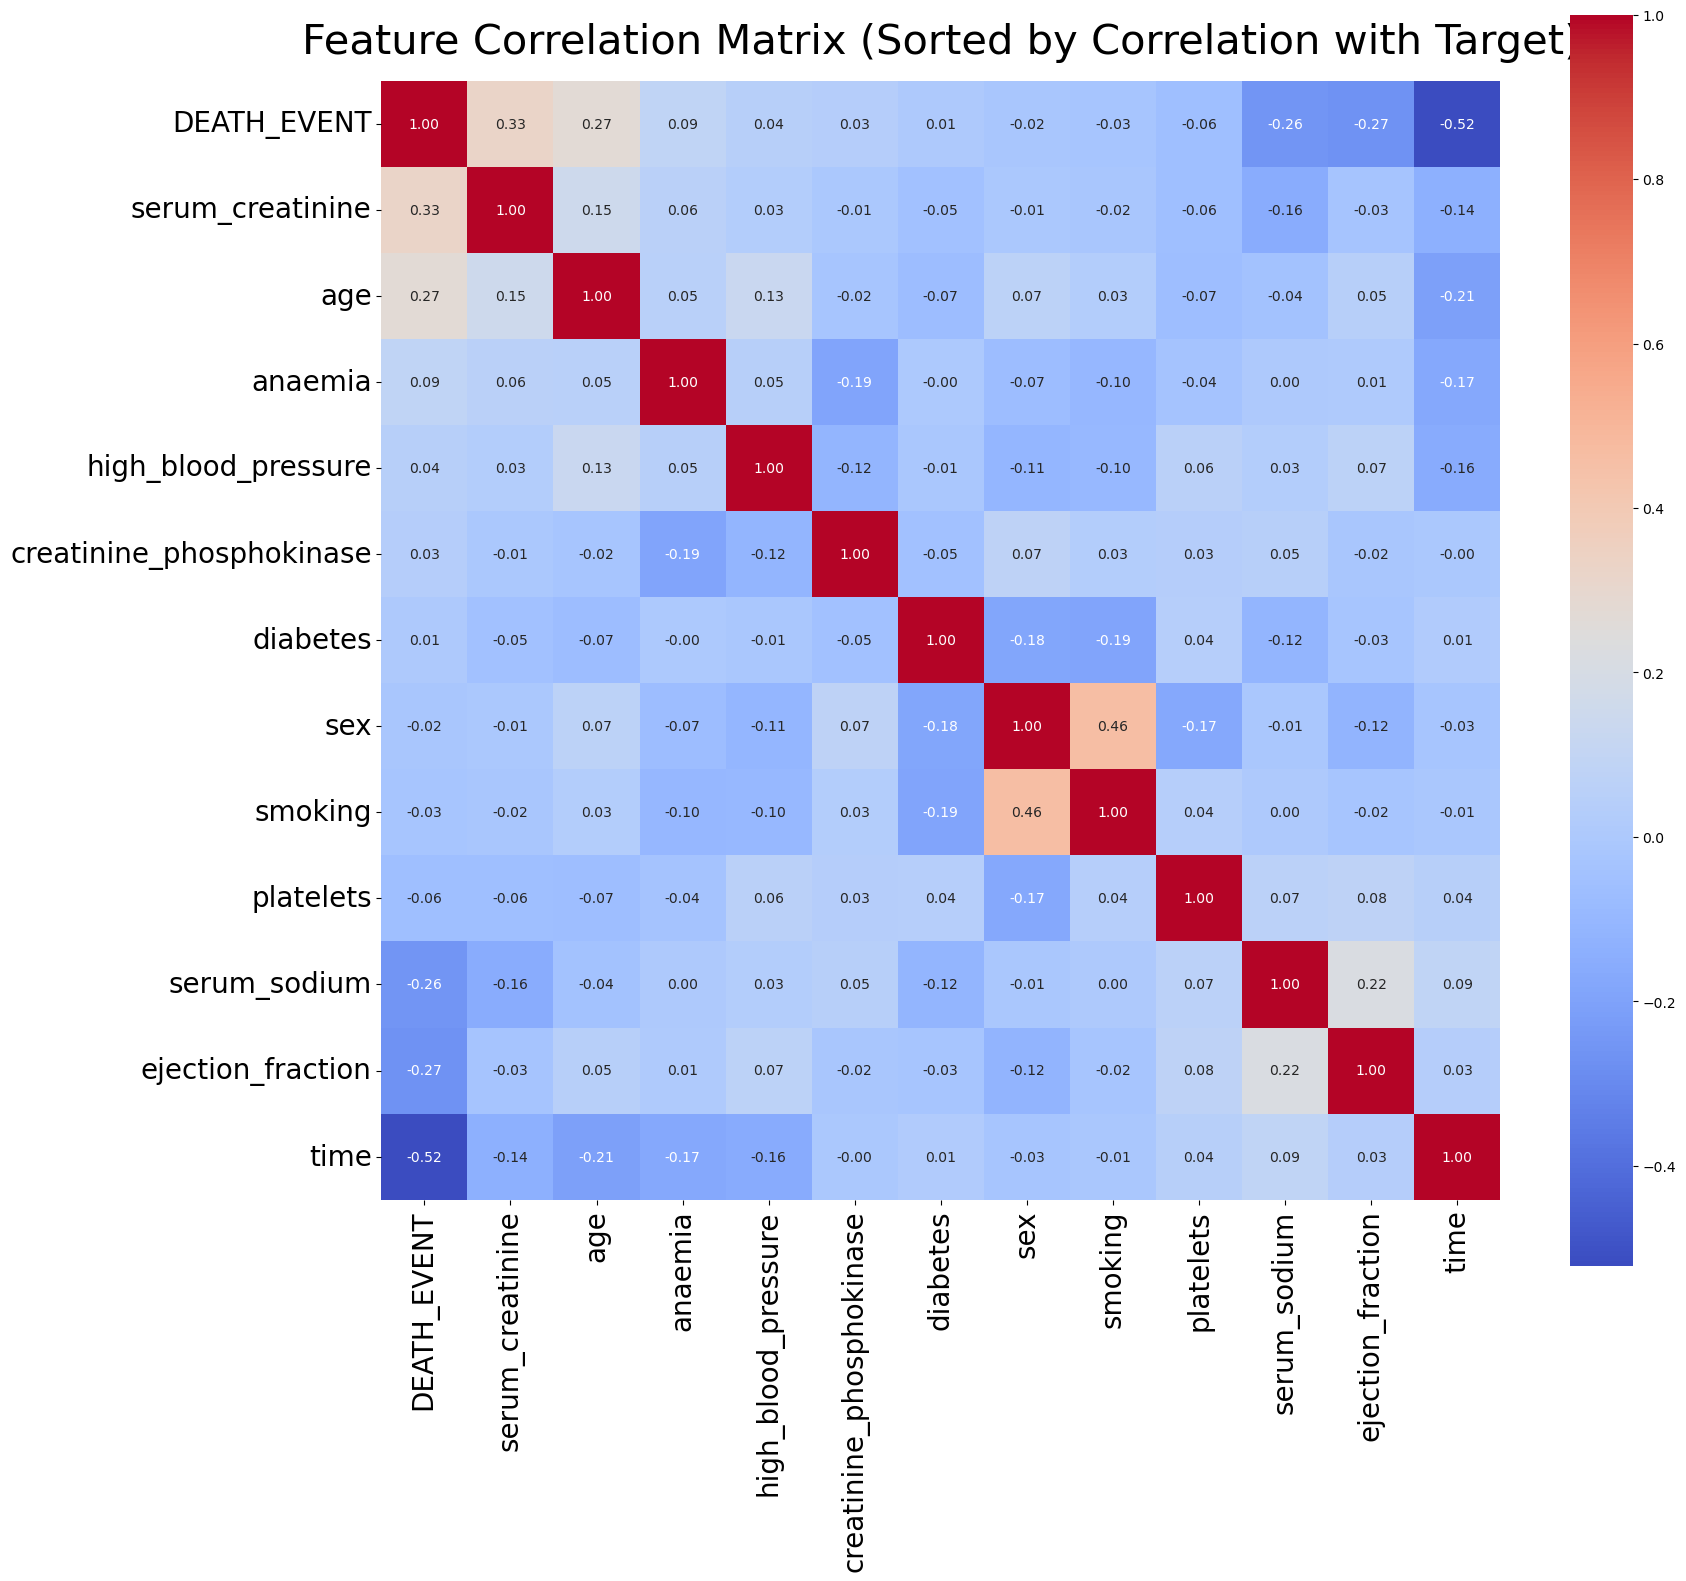

Correlation with DEATH_EVENT:
DEATH_EVENT                 1.000000
serum_creatinine            0.326138
age                         0.273166
anaemia                     0.088886
high_blood_pressure         0.044843
creatinine_phosphokinase    0.031485
diabetes                    0.005338
sex                        -0.021182
smoking                    -0.026766
platelets                  -0.063508
serum_sodium               -0.256762
ejection_fraction          -0.268376
time                       -0.521597
Name: DEATH_EVENT, dtype: float64


In [6]:
# Correlation analysis heatmap

corr_with_target = df.corr()['DEATH_EVENT'].sort_values(ascending=False)
sorted_features = corr_with_target.index.tolist()
corr_sorted = df[sorted_features].corr()


plt.figure(figsize=(18, 16))
sns.heatmap(corr_sorted, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Matrix (Sorted by Correlation with Target)', fontsize=30, pad=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.show()


print("Correlation with DEATH_EVENT:")
print(corr_with_target)

In [7]:
x = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']
x.shape, y.shape

((249, 12), (249,))

In [8]:
# Splitting the data into training and testing sets
x_train, x_valid, y_train, y_valid = train_test_split(x, y, train_size=0.8, random_state=42)
print(x_train.shape)
print(y_train.shape)
print(x_valid.shape)
print(y_valid.shape)

(199, 12)
(199,)
(50, 12)
(50,)


#### Preprocess

In [9]:
x_train = torch.FloatTensor(x_train.values)
y_train = torch.FloatTensor(y_train.values)

x_valid = torch.FloatTensor(x_valid.values)
y_valid = torch.FloatTensor(y_valid.values)

In [10]:
mu = torch.mean(x_train, dim=0)
std = torch.std(x_train, dim=0)

x_train = (x_train - mu) / std
x_valid = (x_valid - mu) / std

#### Dataloader

In [11]:
train_dataset = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

valid_dataset = TensorDataset(x_train, y_train)
valid_loader = DataLoader(train_dataset, batch_size=8, shuffle=False)

#### Save the variables that are needed in other files

In [ ]:
torch.save({'mu': mu, 'std': std, 
            'train_dataset': train_dataset, 
            'valid_loader': valid_loader}, 'variables.pt')

#### MLP Model

In [20]:
in_features = 12
out_features = 1
h1 = 64
h2 = 32

model = nn.Sequential(nn.Linear(in_features, h1),
                      nn.ReLU(),
                      nn.Linear(h1, h2),
                      nn.ReLU(),
                      nn.Linear(h2, out_features),
                      nn.Sigmoid())

model

Sequential(
  (0): Linear(in_features=12, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
  (5): Sigmoid()
)

#### Loss function & Optimizer

In [21]:
loss_fn = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

#### Utils

In [22]:
class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

#### Train

In [23]:
loss_train_hist = []
loss_valid_hist = []

acc_train_hist = []
acc_valid_hist = []

In [24]:
num_epochs = 600

for epoch in range(num_epochs):

    # train
    loss_train = AverageMeter()
    acc_train = Accuracy(task='binary')
    for inputs, targets in train_loader:
        outputs = model(inputs)
        loss = loss_fn(outputs.squeeze(), targets)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss_train.update(loss.item())
        acc_train(outputs.squeeze(), targets)


    loss_train_hist.append(loss_train.avg)
    acc_train_hist.append(acc_train.compute())

    # validation
    with torch.no_grad():
        loss_valid = AverageMeter()
        acc_valid = Accuracy(task='binary')
        for inputs, targets in valid_loader:
            outputs = model(inputs)

            loss = loss_fn(outputs.squeeze(), targets)
            loss_valid.update(loss.item())

            acc_valid(outputs.squeeze(), targets)


    loss_valid_hist.append(loss_valid.avg)
    acc_valid_hist.append(acc_valid.compute())


    if epoch % 10 == 0:
        print(f'Epoch {epoch}')
        print(f'\tTrain Loss = {loss_train.avg:.4f} | Train Accuracy: {acc_train.compute():.4f}')
        print(f'\tValid Loss = {loss_valid.avg:.4f} | Validation Accuracy: {acc_valid.compute():.4f} \n')

Epoch 0
	Train Loss = 0.7120 | Train Accuracy: 0.3216
	Valid Loss = 0.7095 | Validation Accuracy: 0.3317 

Epoch 10
	Train Loss = 0.6749 | Train Accuracy: 0.6784
	Valid Loss = 0.6731 | Validation Accuracy: 0.6784 

Epoch 20
	Train Loss = 0.6494 | Train Accuracy: 0.6834
	Valid Loss = 0.6484 | Validation Accuracy: 0.6834 

Epoch 30
	Train Loss = 0.6309 | Train Accuracy: 0.6834
	Valid Loss = 0.6302 | Validation Accuracy: 0.6834 

Epoch 40
	Train Loss = 0.6160 | Train Accuracy: 0.6834
	Valid Loss = 0.6155 | Validation Accuracy: 0.6834 

Epoch 50
	Train Loss = 0.6039 | Train Accuracy: 0.6834
	Valid Loss = 0.6025 | Validation Accuracy: 0.6834 

Epoch 60
	Train Loss = 0.5910 | Train Accuracy: 0.6834
	Valid Loss = 0.5904 | Validation Accuracy: 0.6834 

Epoch 70
	Train Loss = 0.5783 | Train Accuracy: 0.6834
	Valid Loss = 0.5783 | Validation Accuracy: 0.6834 

Epoch 80
	Train Loss = 0.5673 | Train Accuracy: 0.6834
	Valid Loss = 0.5655 | Validation Accuracy: 0.6834 

Epoch 90
	Train Loss = 0.5535

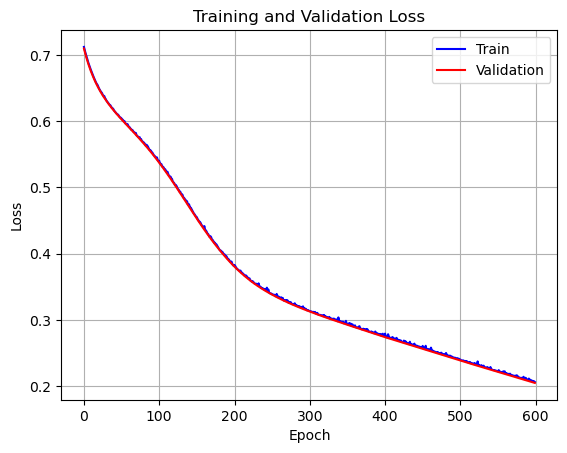

In [25]:
plt.plot(range(num_epochs), loss_train_hist, 'b-', label="Train")
plt.plot(range(num_epochs), loss_valid_hist, 'r-', label="Validation")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

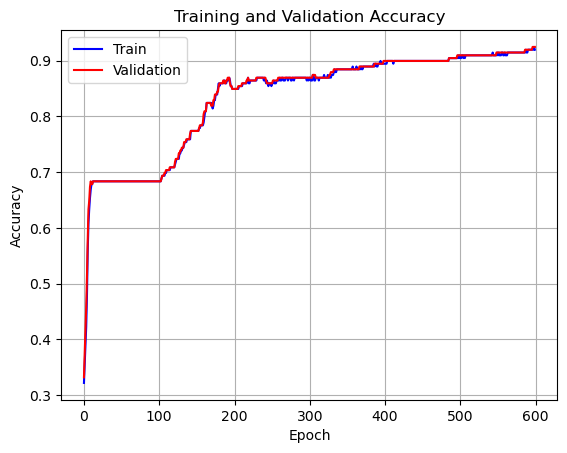

In [26]:
# plot acc_epoch
plt.plot(range(num_epochs), acc_train_hist, 'b-', label="Train")
plt.plot(range(num_epochs), acc_valid_hist, 'r-', label="Validation")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

#### Save model

In [ ]:
torch.save(model, 'model.pth')